In [101]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [44]:
data=pd.read_csv('Housing_v2.csv')

In [45]:
data.describe()

,Price,Bedrooms,Bathrooms,Floor Area,Land Area,Latitude,Longitude
count,1.451000e+03,1437.000000,1420.000000,1463.000000,1477.000000,1211.000000,1211.000000
mean,3.282218e+07,3.617954,3.003169,213.925188,274.173981,14.241230,121.203060
std,1.012451e+08,1.374068,1.854035,236.604771,889.539871,1.750072,0.990405
min,3.000000e+05,1.000000,1.000000,22.000000,27.000000,6.128079,120.228242
25%,4.902000e+06,3.000000,2.000000,67.560000,81.000000,14.372321,120.896277
50%,9.200000e+06,3.000000,3.000000,142.000000,121.000000,14.525747,121.026941
75%,2.500000e+07,4.000000,4.000000,250.000000,240.000000,14.913178,121.074282
max,2.500000e+09,13.000000,43.000000,2200.000000,25000.000000,17.388063,125.803791


In [46]:
def numeric(df):
  numeric_df = df.select_dtypes(include=["int64", "float64"])
  return numeric_df
def categorical(df):
  categorical_df = df.select_dtypes(include=["object"])
  return categorical_df


In [47]:
cat, num = 0, 0
numeric_df = numeric(data)
categorical_df = categorical(data)
for col in data.columns:
    if col in numeric_df.columns:
        num+=1
    else:
        cat+=1
print(f'Categorical columns: {cat} \nNumerical columns: {num}')

missing_values = data.isnull().sum().sum()
#I used data.size instead of len(data) to get the total number of 
# elements in the DataFrame, which is more accurate for calculating 
# the percentage of missing values.
perc_miss_values=(missing_values / data.size) * 100
print(f'Missing values: \n{missing_values} \nPercentage of missing values: \n{perc_miss_values}%')

cardinality=data.nunique()
print(f'Cardinality of each column: \n{cardinality}')

Categorical columns: 2 
Numerical columns: 7
Missing values: 
834 
Percentage of missing values: 
6.177777777777778%
Cardinality of each column: 
Description    1381
Location        664
Price           831
Bedrooms         13
Bathrooms        18
Floor Area      411
Land Area       413
Latitude        459
Longitude       459
dtype: int64


C:\Users\Поліна\AppData\Local\Temp\ipykernel_15040\3150696230.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_df = df.select_dtypes(include=["object"])


In [48]:
def mean(df):
    return sum(df)/len(df)

def median(df):
    sorted_df=sorted(df)
    n=len(sorted_df)
    if n%2==0:
        return(sorted_df[n//2-1]+sorted_df[n//2])/2
    else:
        return sorted_df[n//2]

def std_dev(df):
    m=mean(df)
    return (sum((x-m)**2 for x in df)/len(df))**0.5

def calc_quantile(df, q):
  sorted_df=sorted(df)
  n=len(sorted_df)
  pos=q*(n-1)
  idx=int(pos)
  fraction=pos-idx

  if idx+1<n:
    return sorted_df[idx]+fraction*(sorted_df[idx+1]-sorted_df[idx])
  else:
    return sorted_df[idx]

def mode(df):
    freq_dict={}
    for d in df:
        freq_dict[d]=freq_dict.get(d,0)+1
    sorted_freq=sorted(freq_dict.items(), key=lambda x: x[1], reverse=True)

    mode1=sorted_freq[0][0] if len(sorted_freq) > 0 else None
    freq_1 = sorted_freq[0][1] if len(sorted_freq) > 0 else 0
    perc1=(freq_1 / len(df)) * 100 

    mode2=sorted_freq[1][0] if len(sorted_freq) > 1 else None
    freq_2 = sorted_freq[1][1] if len(sorted_freq) >1 else 0
    perc2=(freq_2 / len(df)) * 100 
    return mode1, freq_1, perc1, mode2, freq_2, perc2

In [49]:
numerical=0
for col in data.columns:
    if col in numeric_df.columns:
        numerical+=1
        total=len(data[col])
        clean_data=data[col].dropna().to_list()

        missing_values = data[col].isnull().sum()
        perc_miss_values=(missing_values / len(data)) * 100
        cardinality=data[col].nunique()

        if len(clean_data) > 0:
            maxim=max(clean_data)
            minim=min(clean_data)
            q1 = calc_quantile(clean_data, 0.25)
            q3 = calc_quantile(clean_data, 0.75)
            mean1=mean(clean_data)
            median1=median(clean_data)
            std1=std_dev(clean_data)
        else:
            maxim = None
            minim = None
            q1 = None
            q3 = None
            mean1 = None
            median1 = None
            std1 = None

        print(f'Column: {col}\n')
        print(f'Total values: {total}')
        print(f"Missing values: {missing_values}")
        print(f"Percentage of missing values: {perc_miss_values}%")
        print(f"Cardinality: {cardinality}")
        print(f"Maximum value: {maxim}")    
        print(f"Minimum value: {minim}")
        print(f"Quartiles: {q1}, {q3}")
        print(f"Mean: {mean1}")
        print(f"Median: {median1}")
        print(f"Standard deviation: {std1}\n")

print(f"Number of numerical columns: {numerical}")


Column: Price

Total values: 1500
Missing values: 49
Percentage of missing values: 3.266666666666666%
Cardinality: 831
Maximum value: 2500000000.0
Minimum value: 300000.0
Quartiles: 4902000.0, 25000000.0
Mean: 32822175.862853203
Median: 9200000.0
Standard deviation: 101210202.6324799

Column: Bedrooms

Total values: 1500
Missing values: 63
Percentage of missing values: 4.2%
Cardinality: 13
Maximum value: 13.0
Minimum value: 1.0
Quartiles: 3.0, 4.0
Mean: 3.617954070981211
Median: 3.0
Standard deviation: 1.3735894352577969

Column: Bathrooms

Total values: 1500
Missing values: 80
Percentage of missing values: 5.333333333333334%
Cardinality: 18
Maximum value: 43.0
Minimum value: 1.0
Quartiles: 2.0, 4.0
Mean: 3.003169014084507
Median: 3.0
Standard deviation: 1.8533820892134838

Column: Floor Area

Total values: 1500
Missing values: 37
Percentage of missing values: 2.466666666666667%
Cardinality: 411
Maximum value: 2200.0
Minimum value: 22.0
Quartiles: 67.56, 250.0
Mean: 213.9251879699248
M

In [50]:
categorical1=0
for col in data.columns:
    if col in categorical_df.columns:
        categorical1+=1
        total=len(data[col])
        clean_data=data[col].dropna().to_list()

        missing_values = data[col].isnull().sum()
        perc_miss_values=(missing_values / len(data)) * 100
        cardinality=data[col].nunique()
        mode1, freq_1, perc1, mode2, freq_2,perc2 = mode(clean_data)

        print(f'Column: {col}\n')
        print(f'Total values: {total}')
        print(f"Missing values: {missing_values}")
        print(f"Percentage of missing values: {perc_miss_values}%")
        print(f"Cardinality: {cardinality}")
        print(f"Mode 1: {mode1} (Percentage: {perc1:.2f}% and Frequency: {freq_1})")
        print(f"Mode 2: {mode2} (Percentage: {perc2:.2f}% and Frequency: {freq_2})\n")

print(f"Number of categorical columns: {categorical1}")


Column: Description

Total values: 1500
Missing values: 0
Percentage of missing values: 0.0%
Cardinality: 1381
Mode 1: 3BR 3-Storey Townhouse for Sale near Alabang in Likha Residences, Muntinlupa | End Unit (Garden Unit) (Percentage: 1.40% and Frequency: 21)
Mode 2: 3BR 3-Storey Townhouse for Sale near Alabang in Likha Residences, Muntinlupa | Typical Unit (Garden Unit) (Percentage: 0.67% and Frequency: 10)

Column: Location

Total values: 1500
Missing values: 4
Percentage of missing values: 0.26666666666666666%
Cardinality: 664
Mode 1: Emilio Vergara Hwy Santa Arcadia, Cabanatuan (Percentage: 4.75% and Frequency: 71)
Mode 2: MacArthur Hwy Anonas, Urdaneta (Percentage: 3.94% and Frequency: 59)

Number of categorical columns: 2


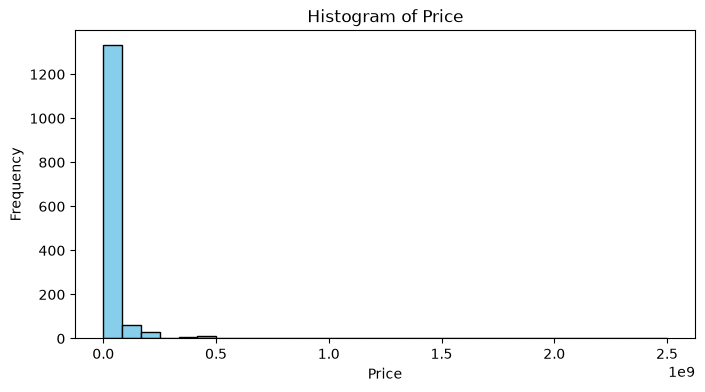

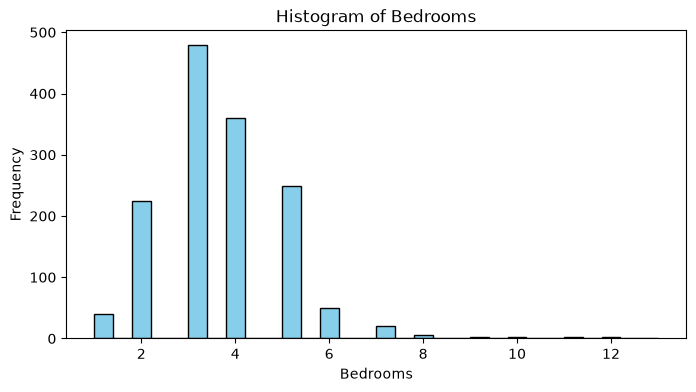

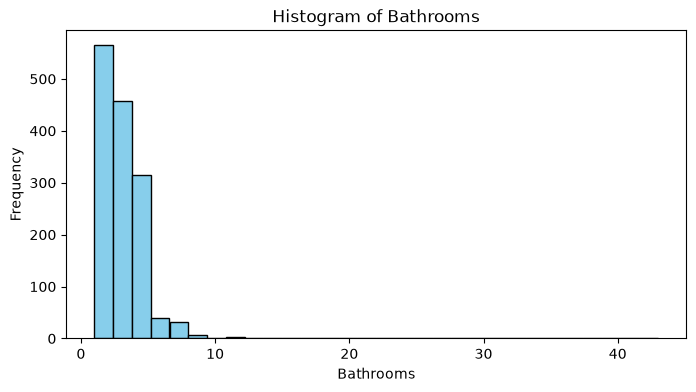

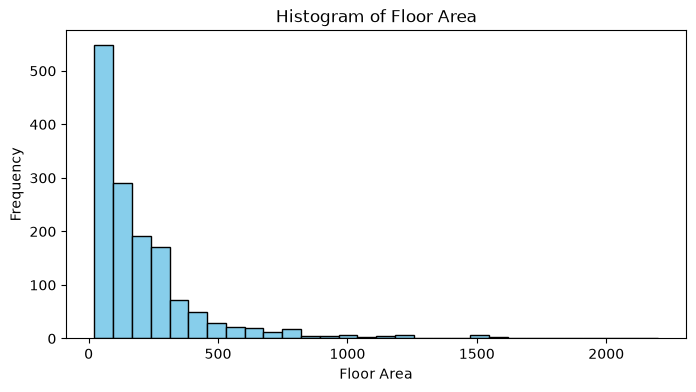

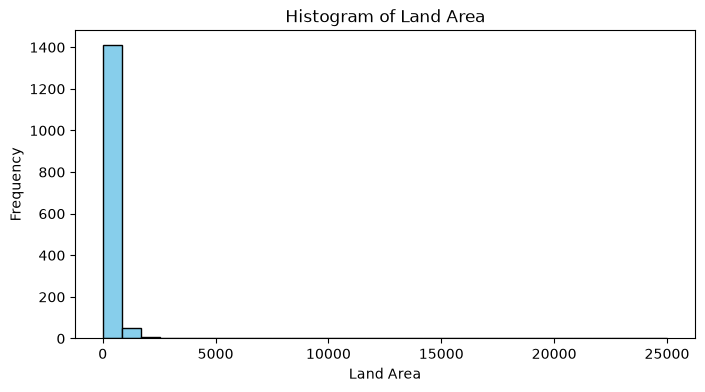

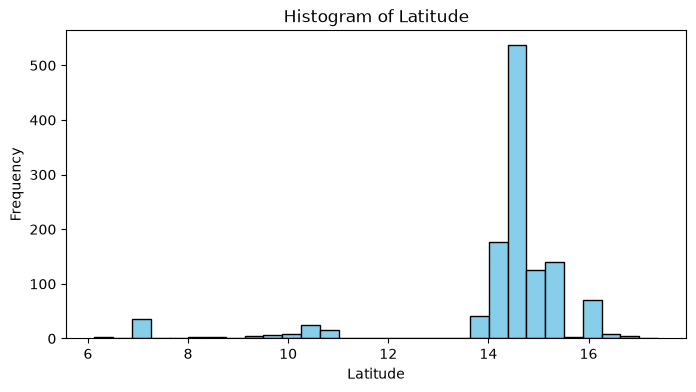

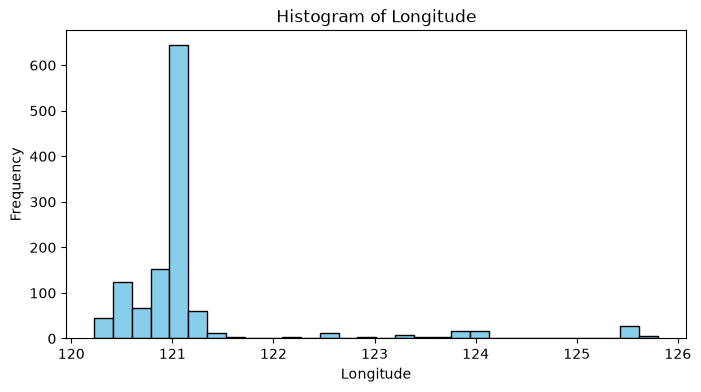

In [51]:
continuous_col=['Price', 'Bedrooms', 'Bathrooms', 'Floor Area', 'Land Area', 'Latitude', 'Longitude']

for col in continuous_col:
    plt.figure(figsize=(8, 4))
    data[col].dropna().plot(kind='hist', bins=30, edgecolor="black", color="skyblue")
    plt.title(f'Histogram of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()


In [52]:
total_miss_values = data.isnull().sum().sum()
perc=(total_miss_values / data.size) * 100
print(f'Total missing values per column:\n{total_miss_values}\n'
        f'Percentage of missing values:\n{perc}%\n')



Total missing values per column:
834
Percentage of missing values:
6.177777777777778%



In [53]:
for col in data.columns:
  if data[col].dtype in ["int64", "float64"]:
    clean_vals = data[col].dropna().tolist()
    if len(clean_vals) > 0:
      q1=calc_quantile(clean_vals , 0.25)
      q3=calc_quantile(clean_vals, 0.75)
      iqr = q3 - q1
      lower_bound = q1 - 1.5 * iqr
      upper_bound = q3 + 1.5 * iqr
      outliers = data[(data[col] < lower_bound) | (data[col] > upper_bound)].shape[0]
      outliers_perc = (outliers / len(data)) * 100
      print(f'Column: {col}\n')
      print(f'Number of outliers: {outliers}')
      print(f'Percentage of outliers: {outliers_perc}%\n')

Column: Price

Number of outliers: 162
Percentage of outliers: 10.8%

Column: Bedrooms

Number of outliers: 125
Percentage of outliers: 8.333333333333332%

Column: Bathrooms

Number of outliers: 12
Percentage of outliers: 0.8%

Column: Floor Area

Number of outliers: 113
Percentage of outliers: 7.533333333333333%

Column: Land Area

Number of outliers: 156
Percentage of outliers: 10.4%

Column: Latitude

Number of outliers: 190
Percentage of outliers: 12.666666666666668%

Column: Longitude

Number of outliers: 327
Percentage of outliers: 21.8%



In [54]:
duplicates_count = data.duplicated().sum()
print(f"Number of duplicates: {duplicates_count}")

Number of duplicates: 77


In [55]:
invalid_prices = data[data["Price"] <= 0].shape[0] if "Price" in data.columns else 0
invalid_area = data[data["Floor Area"] <= 0].shape[0] if "Floor Area" in data.columns else 0
print(f"Invalid price values (<= 0): {invalid_prices}")
print(f"Invalid area values (<= 0): {invalid_area}")

Invalid price values (<= 0): 0
Invalid area values (<= 0): 0


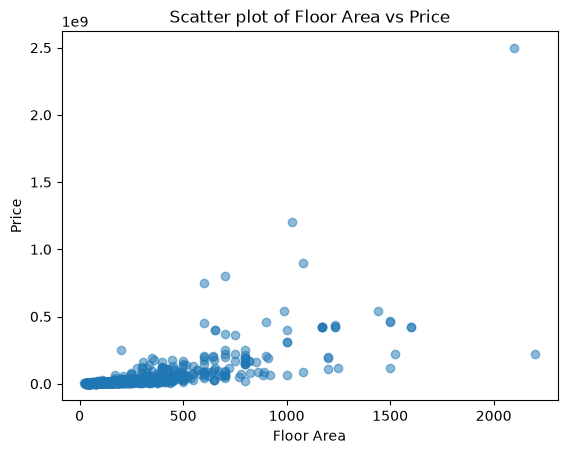

In [56]:
x=data['Floor Area']
y=data['Price']

plt.scatter(x, y, alpha=0.5)
plt.title('Scatter plot of Floor Area vs Price')
plt.xlabel('Floor Area')
plt.ylabel('Price')
plt.show()

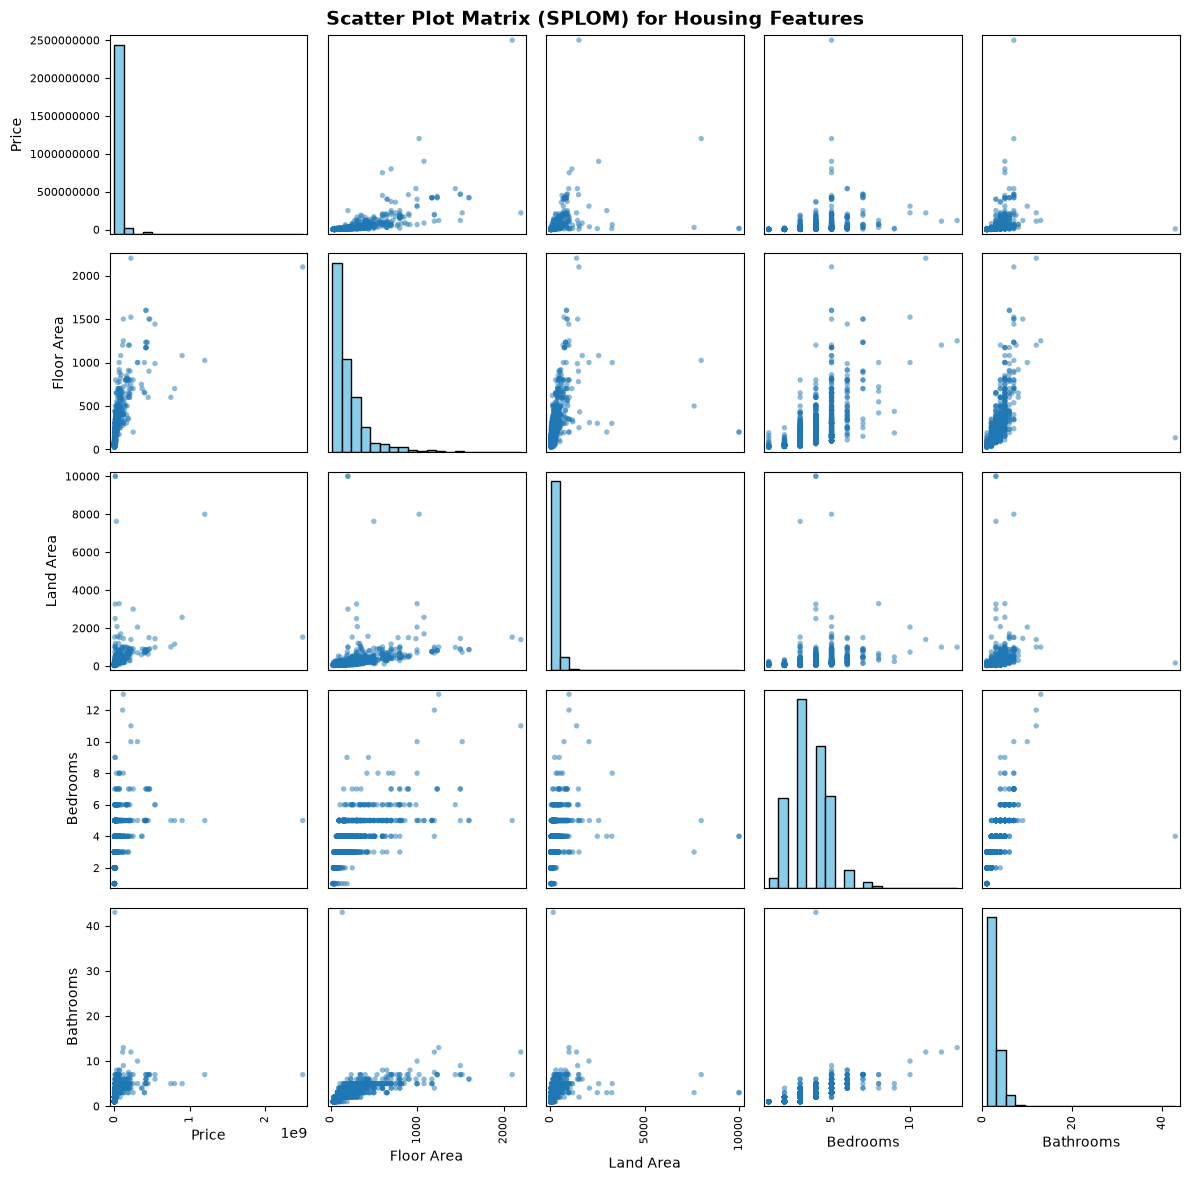

In [57]:
cols_for_splom = ["Price", "Floor Area", "Land Area", "Bedrooms", "Bathrooms"]
splom_data = data[cols_for_splom].dropna()
pd.plotting.scatter_matrix(
    splom_data,
    figsize=(12, 12),
    marker="o",
    hist_kwds={"bins": 20, "color": "skyblue", "edgecolor": "black"},
    alpha=0.5,  # Transparency for overlapping data points
    s=15,  # Marker size
)
plt.suptitle(
    "Scatter Plot Matrix (SPLOM) for Housing Features",
    fontsize=14,
    fontweight="bold",
)
plt.tight_layout()
plt.show()

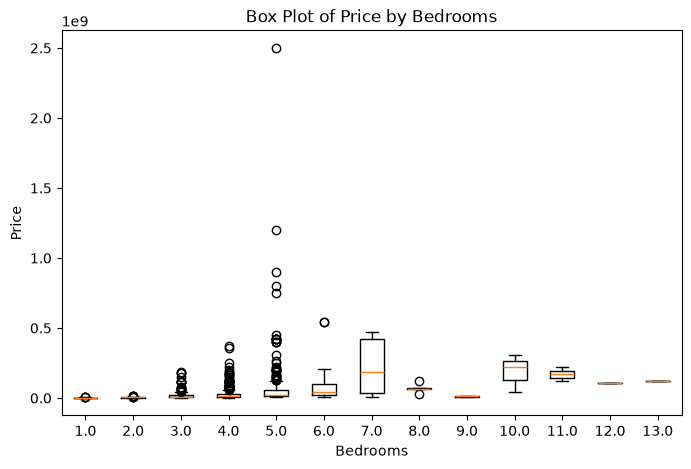

In [58]:
df_clean = data.dropna(subset=["Bedrooms", "Price"])
unique_bedrooms = sorted(df_clean["Bedrooms"].unique())
box_data = [df_clean[df_clean["Bedrooms"] == b]["Price"] for b in unique_bedrooms]

plt.figure(figsize=(8, 5))
plt.boxplot(box_data, tick_labels=unique_bedrooms)
plt.title("Box Plot of Price by Bedrooms")
plt.xlabel("Bedrooms")
plt.ylabel("Price")
plt.show()

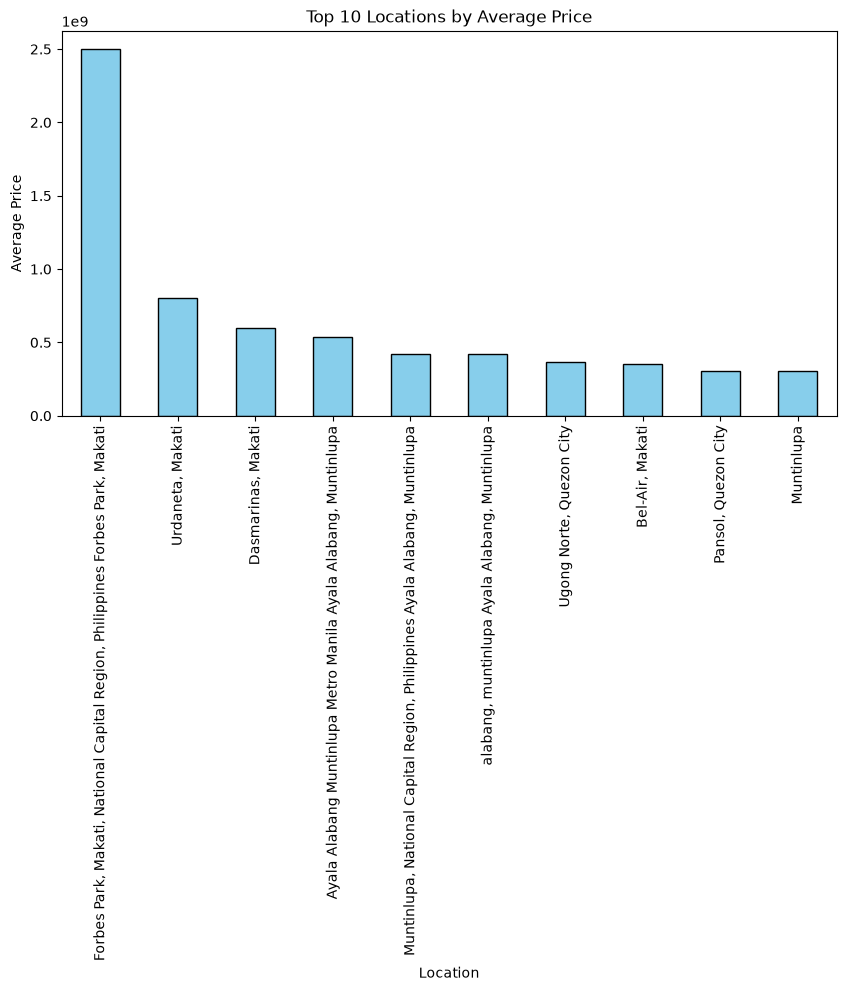

In [59]:
top_locations = (
    data.groupby("Location")["Price"].mean().nlargest(10))

plt.figure(figsize=(10, 5))
top_locations.plot(kind="bar", color="skyblue", edgecolor="black")
plt.title("Top 10 Locations by Average Price")
plt.xlabel("Location")
plt.ylabel("Average Price")
plt.show()

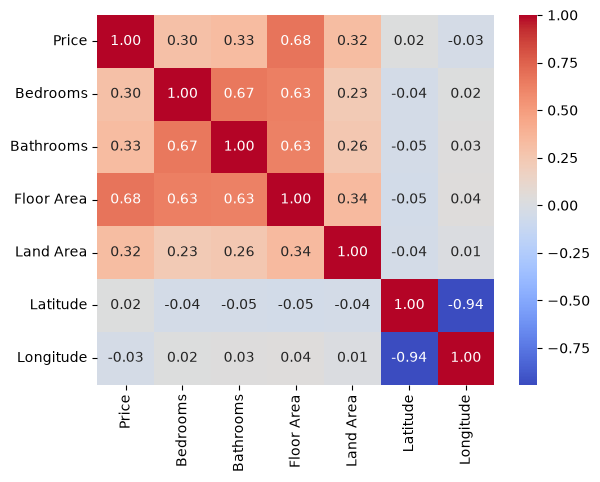

In [60]:
num=numeric(data)
correlation_matrix = num.corr()
ax=sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)


In [61]:
def train_test(df, test_size=0.2):
    n=len(df)
    train_size=int(n*(1-test_size))
    #iloc is used to select rows by index position
    return df.iloc[:train_size], df.iloc[train_size:]

train_data, test_data = train_test(data, test_size=0.2)

In [62]:
train_num_col=numeric(train_data).columns
train_cat_col=categorical(train_data).columns

train_medians={}
for col in train_num_col:
    clean_vals=train_data[col].dropna().tolist()
    train_medians[col]=median(clean_vals)

train_modes={}
for col in train_cat_col:
    clean_vals=train_data[col].dropna().tolist()
    train_modes[col]=mode(clean_vals)[0]

def fill_missing_values(df):
    df_copy=df.copy()
    for col, val in train_medians.items():
        df_copy[col]=df_copy[col].fillna(val)
    for col, val in train_modes.items():
        df_copy[col]=df_copy[col].fillna(val)
    return df_copy

train_data=fill_missing_values(train_data)
test_data=fill_missing_values(test_data)


C:\Users\Поліна\AppData\Local\Temp\ipykernel_15040\3150696230.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_df = df.select_dtypes(include=["object"])


In [63]:
train_data['Total_Rooms'] = train_data['Bedrooms'] + train_data['Bathrooms']
train_data['Total_Area'] = train_data['Floor Area'] + train_data['Land Area']
test_data['Total_Rooms'] = test_data['Bedrooms'] + test_data['Bathrooms']
test_data['Total_Area'] = test_data['Floor Area'] + test_data['Land Area']
train_num_col = numeric(train_data).columns

In [64]:
outlier_columns = ['Price','Bedrooms','Bathrooms','Floor Area','Land Area']
train_iqr={}
for col in outlier_columns:
    clean_vals=train_data[col].dropna().tolist()
    if clean_vals:
        q1=calc_quantile(clean_vals, 0.25)
        q3=calc_quantile(clean_vals, 0.75)
        iqr = q3 - q1
        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr
        train_iqr[col] = (lower_bound, upper_bound)

def cap_outliers(df):
    df_copy=df.copy()
    for col, (lower_bound, upper_bound) in train_iqr.items():
        df_copy[col]=df_copy[col].apply(lambda x: max(lower_bound, min(upper_bound, x)))
    return df_copy

train_data=cap_outliers(train_data)
test_data=cap_outliers(test_data)


In [65]:
unique={}
for col in train_cat_col:
    unique[col]=train_data[col].unique().tolist()

for col, cats in unique.items():
    print(f"Column '{col}': {cats}")
    
def one_hot_encode(df):
    df_copy=df.copy()
    for col, cats in unique.items():
        for cat in cats:
            new_col_name=f"{col}_{cat}"
            binary_values=[]
            for val in df_copy[col]:
                if val==cat:
                    binary_values.append(1)
                else:
                    binary_values.append(0)
            
            df_copy[new_col_name]=binary_values
        df_copy=df_copy.drop(columns=[col])
    return df_copy

train_data=one_hot_encode(train_data)
test_data=one_hot_encode(test_data)

C:\Users\Поліна\AppData\Local\Temp\ipykernel_15040\1114010254.py:20: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_copy[new_col_name]=binary_values


Column 'Description': ['Preselling 2-Storey Townhouses in Village East Executive Subdivision, Cainta', 'Affordable House & Lot with Complete Amenities for Sale in Santa Maria, Bulacan', '5BR 2-Storey House and Lot for Sale in Tarlac City at Camella Tarlac | Ella 110sqm', 'Maya Solo 3 Bedrooms Single Detached House for Sale in Gabon, Abucay, Bataan', 'Futura Homes Zamboanga | Amber 2BR Townhouse End Unit for Sale in Zamboanga City | Futura by Filinvest', 'Springfield View | Molave House and Lot for Sale in Tanza, Cavite | Futura by Filinvest', '2BR 2-Storey Townhouse for Sale at Marytown Place Ph2 in Santa Maria, Bulacan | Inner Unit (IRIS)', '5BR 2-Storey House and Lot for Sale in Subic, Zambales at Camella Subic | Freya 121sqm', '2-Bedroom House and Lot For Sale in Camella Pili', '3BR 3-Storey Townhouse for Sale near Alabang in Likha Residences, Muntinlupa | End Unit (Garden Unit)', '3-Bedroom House for Sale in Mexico, Pampanga at The Lakeshore | Akan Model', '3BR 2-Storey Townhouse f

In [66]:
train_min={}
train_max={}

for col in train_num_col:
    clean_vals=train_data[col].dropna().tolist()
    if clean_vals:
        train_min[col]=min(clean_vals)
        train_max[col]=max(clean_vals)

def normalize(df):
    df_copy=df.copy()
    for col in train_num_col:
        min_val=train_min[col]
        max_val=train_max[col]
        if max_val != min_val:
            df_copy[col] = (df_copy[col] - min_val) / (max_val - min_val)
        else:
            df_copy[col] = 0.0    
    return df_copy

train_data = normalize(train_data)
test_data = normalize(test_data)

In [67]:
X_train_df = train_data.drop(columns=['Price'])
y_train_series = train_data['Price']
X_train_list = X_train_df.values.tolist()
y_train_list = y_train_series.tolist()

X_test_df = test_data.drop(columns=['Price'])
y_test_series = test_data['Price']
X_test_list = X_test_df.values.tolist()
y_test_list = y_test_series.tolist()

In [68]:
#least squared
X_train_with_bias=[]
for i in range(len(X_train_list)):
    row=[1.0]
    for j in range(len(X_train_list[i])):
        row.append(X_train_list[i][j])
    X_train_with_bias.append(row)

X_np=np.array(X_train_with_bias)
y_np=np.array(y_train_list)
theta_osl=np.linalg.pinv(X_np.T@X_np)@X_np.T@y_np
coefficients_osl=theta_osl.tolist()
print("Coefficients from osl:")
print(coefficients_osl)

Coefficients from osl:
[9.642516758042188, -2.361580118906854, -1.6150786271120765, 0.20214351691044932, 0.6164524728130122, -13.828335561935887, 3.629439447373082, 20.765296605446657, 1.0287320646037776e-07, 0.4591858514576881, 0.5937051574154633, 0.26417129244136106, 0.7278958455625348, -3.339988765759431, 0.25675848607892693, 0.012223563780013436, 0.23470775661840604, 0.37062628516929474, -0.8431476761925354, 0.25553410705503554, -1.6409353402608815, 0.26647148560918266, 0.37504562180111467, 0.21028850703039656, -0.8698910996091622, 0.17915983384740242, 0.2664714853054685, 0.04158729611133016, 0.06208210951831705, -0.11607053452464156, 0.14009407663762838, 0.20654419109457078, 0.14976657896108103, -1.6409353380194682, 0.19567836318752396, 0.04411724641310366, 0.10938049061443778, 0.10738536975885371, 0.1732487502699438, 0.11969616257645233, -2.025010985065718, 0.27821556484275467, -0.11468490386240643, 0.06866769496680192, 0.2836969005294576, -0.7808624698587843, 0.3743803225758231,

In [74]:
#gradient
def compute_gradient(X_np, y_np, theta):
    m=len(y_np)
    X_transpose=X_np.T
    predictions=X_np@theta
    error=predictions-y_np
    grad=(1/m)*(X_transpose@error)
    return grad

def gradient_descend(X_with_bias, y_train_list, learning_rate=0.1, epochs=10000):
    X_np=np.array(X_with_bias)
    y_np=np.array(y_train_list).reshape(-1)

    m,n=X_np.shape
    theta_gd=np.zeros(n)
    for epoch in range(epochs):
        grad=compute_gradient(X_np, y_np, theta_gd)
        theta_gd=theta_gd-learning_rate*grad
    return theta_gd.tolist()

coefficients_grad=gradient_descend(X_train_with_bias, y_train_list, learning_rate=0.3, epochs=50000)
print("Coefficients from gradient desc:")
print(coefficients_grad)

Coefficients from gradient desc:
[0.0650338077942946, -0.14607639650138535, 0.2127922255949101, 0.5047061208852673, 0.23032892955885484, -0.03970436322826363, -0.15511855847565964, -0.03043508709789448, 0.0034574588036319536, -0.025038945844673012, -0.0039554508945153, 0.002743510418078753, 0.03195299943634198, 0.006252801745680625, -0.03296771084313978, -0.0409875942718393, -0.014509158415002742, 0.01339534548463359, 0.10327631309789012, -0.020597641042663352, 0.025300189847469543, 0.0013215898687720601, -0.06416609904789676, 0.2611311703371536, 0.021966887288050834, -0.016278022173383744, 0.0013215898687720593, -0.0730987941170942, 0.06837184247298758, -0.03474413780239084, 0.002731727352509242, -0.030854665970513256, 0.013192907008823652, 0.025300189847469543, 0.02869495625768546, 0.054047725652775463, -0.03246177319666262, -0.08830257719643875, 0.02261400194889475, -0.012872063437186892, -0.30609518482715564, -0.010266458816641922, -0.022235347052863983, 0.06856591272654816, -0.019

In [75]:
grad=np.array(coefficients_grad)
osl=np.array(coefficients_osl)

print(len(osl), len(grad))

1584 1584


In [76]:
grad=np.array(coefficients_grad)
osl=np.array(coefficients_osl)
parameter_names = [f'b_{i}' for i in range(len(osl))]
parameter_names[0] = 'Intercept, b0'  
results_df = pd.DataFrame({
    'Parameter': parameter_names,
    'Least squared': osl,
    'Gradient desc': grad,
    'Absolute difference': np.abs(osl - grad),
})


print(results_df.head(10).to_string(index=False))

    Parameter  Least squared  Gradient desc  Absolute difference
Intercept, b0   9.642517e+00       0.065034             9.577483
          b_1  -2.361580e+00      -0.146076             2.215504
          b_2  -1.615079e+00       0.212792             1.827871
          b_3   2.021435e-01       0.504706             0.302563
          b_4   6.164525e-01       0.230329             0.386124
          b_5  -1.382834e+01      -0.039704            13.788631
          b_6   3.629439e+00      -0.155119             3.784558
          b_7   2.076530e+01      -0.030435            20.795732
          b_8   1.028732e-07       0.003457             0.003457
          b_9   4.591859e-01      -0.025039             0.484225


In [81]:
lambda_reg = 1.0
m_samples, n_features = X_np.shape
identity_matrix = np.eye(n_features)
identity_matrix[0, 0] = (0)
theta_ridge_analytical = (np.linalg.inv(X_np.T @ X_np + lambda_reg * identity_matrix)@ X_np.T@ y_np)

def compute_gradient_ridge(X_np, y_np, theta, lambda_reg):
  m = len(y_np)
  X_transpose = X_np.T
  predictions = X_np @ theta
  error = predictions - y_np
  reg_term = (lambda_reg / m) * theta
  reg_term[0] = 0
  grad = (1 / m) * (X_transpose @ error) + reg_term
  return grad

def gradient_descend_ridge(X_with_bias, y_train_list, learning_rate=0.1, epochs=20000, lambda_reg=0.1):
  X_np = np.array(X_with_bias)
  y_np = np.array(y_train_list).reshape(-1)
  m, n = X_np.shape
  theta_gd = np.zeros(n)
  for epoch in range(epochs):
    grad = compute_gradient_ridge(X_np, y_np, theta_gd, lambda_reg)
    theta_gd = theta_gd - learning_rate * grad
  return theta_gd

coefficients_ridge_ols = theta_ridge_analytical.tolist()
print("Coefficients from least squared with regularization:")
print(coefficients_ridge_ols[:10])  

coefficients_grad = gradient_descend_ridge(X_train_with_bias,y_train_list,learning_rate=0.1,epochs=20000,lambda_reg=1.0,)
print("Coefficients from gradient desc with regularization:")
print(coefficients_grad[:10])  

Coefficients from least squared with regularization:
[0.01340041662656341, -0.12356748001959755, 0.1878212051288205, 0.4978823101443549, 0.2516507671018404, 0.013701726465545405, -0.10821905245789976, -0.01885634490864213, -0.025974854746853706, -0.021562422806523256]
Coefficients from gradient desc with regularization:
[ 0.00918746 -0.12303883  0.18727516  0.49755388  0.25228052  0.01817912
 -0.10463108 -0.01842287 -0.02732226 -0.02160715]


In [82]:
osl = np.array(coefficients_ridge_ols)
grad = np.array(coefficients_grad)

parameter_names = [f'b_{i}' for i in range(len(osl))]
parameter_names[0] = 'Intercept, b0'

results_df = pd.DataFrame({
    'Parameter': parameter_names,
    'Ridge OLS (Analytical)': osl,
    'Ridge Gradient Desc': grad,
    'Absolute difference': np.abs(osl - grad),
})

print(results_df.head(10).to_string(index=False))

    Parameter  Ridge OLS (Analytical)  Ridge Gradient Desc  Absolute difference
Intercept, b0                0.013400             0.009187             0.004213
          b_1               -0.123567            -0.123039             0.000529
          b_2                0.187821             0.187275             0.000546
          b_3                0.497882             0.497554             0.000328
          b_4                0.251651             0.252281             0.000630
          b_5                0.013702             0.018179             0.004477
          b_6               -0.108219            -0.104631             0.003588
          b_7               -0.018856            -0.018423             0.000433
          b_8               -0.025975            -0.027322             0.001347
          b_9               -0.021562            -0.021607             0.000045


In [85]:
def cross_validation(X_df, y_list, k=5, learning_rate=0.1, epochs=5000, lambda_reg=1.0):
    X_data=X_df.values #from dataframe to numpy 2d array
    X_with_bias=np.c_[np.ones(X_data.shape[0]), X_data] #add col of 1
    X_arr=np.array(X_train_with_bias)
    y_arr=np.array(y_train_list)

    fold_size=len(X_arr)//k
    mse_scores=[]

    for i in range(k):
        start_idx=i*fold_size
        end_idx=(i+1)*fold_size if i!=k-1 else len(X_arr)
        X_val = X_arr[start_idx:end_idx]
        y_val = y_arr[start_idx:end_idx]
        X_trn = np.concatenate([X_arr[:start_idx], X_arr[end_idx:]], axis=0)
        y_trn = np.concatenate([y_arr[:start_idx], y_arr[end_idx:]], axis=0)
        theta=gradient_descend_ridge(X_trn, y_trn.tolist(), learning_rate=0.1, epochs=10000, lambda_reg=1.0)
        predictions=X_val@theta
        mse=np.mean((predictions-y_val)**2)
        mse_scores.append(mse)
    return mse_scores

In [88]:
full_coef=osl[1:]
sorted_indices = np.argsort(np.abs(full_coef))[::-1]
X_top3_df = X_train_df.iloc[:, sorted_indices[:3]]       
X_sig_df = X_train_df.iloc[:, sorted_indices[:15]]       
X_all_df = X_train_df    
mse_top3 = cross_validation(X_top3_df, y_train_list)
mse_sig = cross_validation(X_sig_df, y_train_list)
mse_all = cross_validation(X_all_df, y_train_list)        
summary_df = pd.DataFrame({
    "Model Case": ["ii. Top 3 Variables", "i. Significant Variables", "iii. All Variables"],
    "Mean MSE": [np.mean(mse_top3), np.mean(mse_sig), np.mean(mse_all)],
    "Std Dev MSE": [np.std(mse_top3), np.std(mse_sig), np.std(mse_all)]
})

print(summary_df.to_string(index=False))               

              Model Case  Mean MSE  Std Dev MSE
     ii. Top 3 Variables  0.022425     0.015501
i. Significant Variables  0.022425     0.015501
      iii. All Variables  0.022425     0.015501


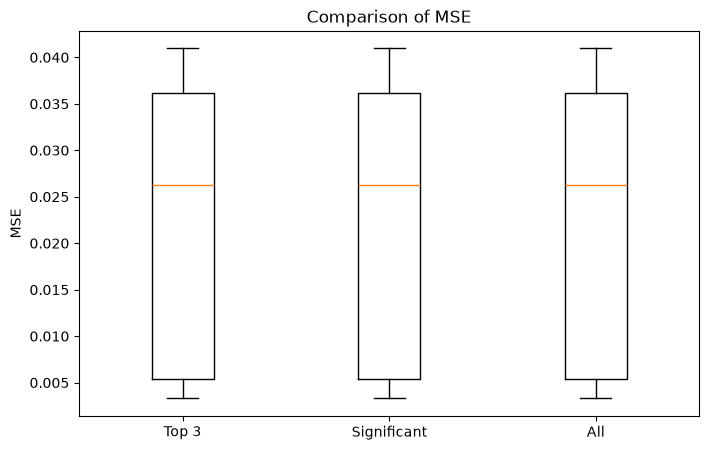

In [90]:
plt.figure(figsize=(8,5))
plt.boxplot([mse_top3, mse_sig, mse_all], tick_labels=["Top 3", "Significant", "All"])
plt.title("Comparison of MSE")
plt.ylabel("MSE")
plt.show()

In [91]:
X_test_top3 = X_test_df.iloc[:, sorted_indices[:3]].values
X_test_sig = X_test_df.iloc[:, sorted_indices[:15]].values
X_test_all = X_test_df.values
X_test_top3_bias = np.c_[np.ones(X_test_top3.shape[0]), X_test_top3]
X_test_sig_bias = np.c_[np.ones(X_test_sig.shape[0]), X_test_sig]
X_test_all_bias = np.c_[np.ones(X_test_all.shape[0]), X_test_all]

theta_top3 = gradient_descend_ridge(np.c_[np.ones(X_top3_df.shape[0]), X_top3_df.values],y_train_list,learning_rate=0.1,epochs=10000,lambda_reg=1.0,)
theta_sig = gradient_descend_ridge(np.c_[np.ones(X_sig_df.shape[0]), X_sig_df.values],
    y_train_list,learning_rate=0.1,epochs=10000,lambda_reg=1.0,)
theta_all = gradient_descend_ridge(X_train_with_bias,
    y_train_list,learning_rate=0.1,epochs=10000,lambda_reg=1.0,)

pred_top3 = X_test_top3_bias @ theta_top3
pred_sig = X_test_sig_bias @ theta_sig
pred_all = X_test_all_bias @ theta_all

y_test_arr = np.array(y_test_list)

In [92]:
def evaluate_metrics(y_true, y_pred):
  mse = np.mean((y_true - y_pred) ** 2)
  rmse = np.sqrt(mse)
  mae = np.mean(np.abs(y_true - y_pred))
  return {"MSE": mse, "RMSE": rmse, "MAE": mae}

metrics_top3 = evaluate_metrics(y_test_arr, pred_top3)
metrics_sig = evaluate_metrics(y_test_arr, pred_sig)
metrics_all = evaluate_metrics(y_test_arr, pred_all)

test_results_df = pd.DataFrame(
    [
        {"Model": "ii. Top 3 Variables", **metrics_top3},
        {"Model": "i. Significant Variables", **metrics_sig},
        {"Model": "iii. All Variables", **metrics_all},
    ]
)
print(test_results_df.to_string(index=False))

                   Model      MSE     RMSE      MAE
     ii. Top 3 Variables 0.034878 0.186756 0.128475
i. Significant Variables 0.033914 0.184158 0.125374
      iii. All Variables 0.032290 0.179695 0.125867


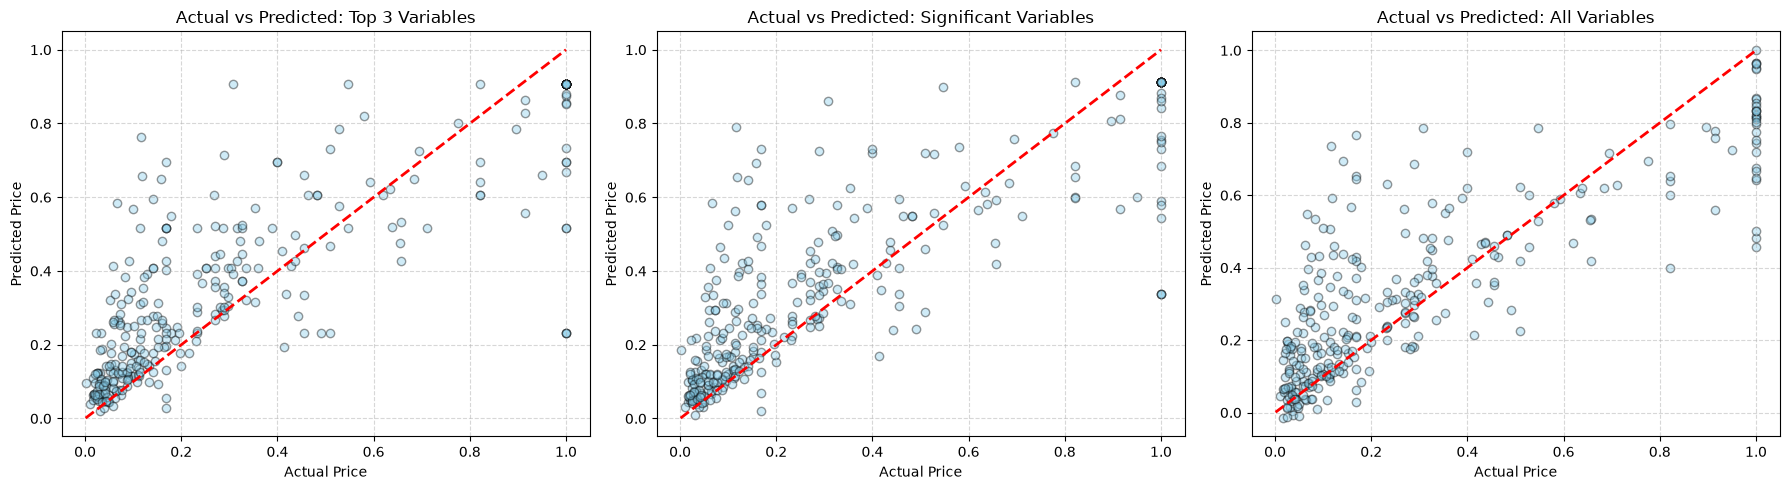

In [95]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
models_preds = [
    ("Top 3 Variables", pred_top3),
    ("Significant Variables", pred_sig),
    ("All Variables", pred_all),
]

for i, (name, preds) in enumerate(models_preds):
  axes[i].scatter(y_test_arr, preds, alpha=0.4, color="skyblue", edgecolors="k")
  axes[i].plot([y_test_arr.min(), y_test_arr.max()],[y_test_arr.min(), y_test_arr.max()],"r--",lw=2,)
  axes[i].set_title(f"Actual vs Predicted: {name}")
  axes[i].set_xlabel("Actual Price")
  axes[i].set_ylabel("Predicted Price")
  axes[i].grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

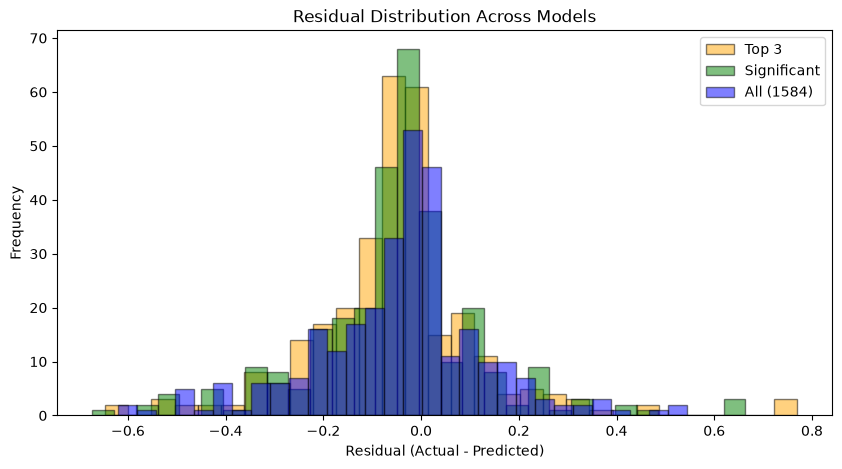

In [100]:
plt.figure(figsize=(10, 5))
plt.hist(y_test_arr - pred_top3,bins=30,alpha=0.5,label="Top 3",color="orange",edgecolor="black",)
plt.hist(y_test_arr - pred_sig,bins=30,alpha=0.5,label="Significant",color="green",edgecolor="black",)
plt.hist(y_test_arr - pred_all, bins=30,alpha=0.5,label="All (1584)",color="blue",edgecolor="black",)
plt.title("Residual Distribution Across Models")
plt.xlabel("Residual (Actual - Predicted)")
plt.ylabel("Frequency")
plt.legend()
plt.show()

In [102]:
sk_ridge=Ridge(alpha=0.1)
sk_ridge.fit(X_sig_df, y_train_list)
sk_preds=sk_ridge.predict(X_test_sig)
sk_mse=mean_squared_error(y_test_arr, sk_preds)
sk_rmse=np.sqrt(sk_mse)
sk_mae=mean_absolute_error(y_test_arr, sk_preds)

print("Scikit-Learn Ridge Metrics (Significant Features):")
print(f"MSE: {sk_mse:.6f}")
print(f"RMSE: {sk_rmse:.6f}")
print(f"MAE: {sk_mae:.6f}")

Scikit-Learn Ridge Metrics (Significant Features):
MSE: 0.034023
RMSE: 0.184454
MAE: 0.124202


c:\Users\Поліна\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but Ridge was fitted with feature names
  warnings.warn(


In [103]:
def predict_single_house(feature_row, theta):
    row_with_bias=np.insert(feature_row.values, 0, 1.0)
    predicted_price=np.dot(row_with_bias, theta)
    return predicted_price

sample_house=X_sig_df.iloc[0]
price=predict_single_house(sample_house, theta_sig)
print(f"Predicted price is : {price}")

Predicted price is : 0.2305943063644398
